# House Price Prediction using Linear Regression

## Project Overview

This project develops a machine learning model to predict house prices using property-related features.

The workflow covers data loading, exploratory data analysis, feature selection, preprocessing, categorical encoding, model training, evaluation, visualization, and coefficient analysis.

## Objectives

- Explore and understand the housing dataset
- Identify important predictors of house prices
- Handle missing values and categorical variables
- Prepare features for machine learning
- Train a Linear Regression model
- Evaluate model performance using MSE, RMSE, and R²
- Compare actual and predicted prices
- Analyze model coefficients
- Generate business-oriented insights

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the housing dataset

df = pd.read_csv("../dataset/Housing.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# Initial dataset assessment

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDescriptive Statistics:")
df.describe()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom     

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


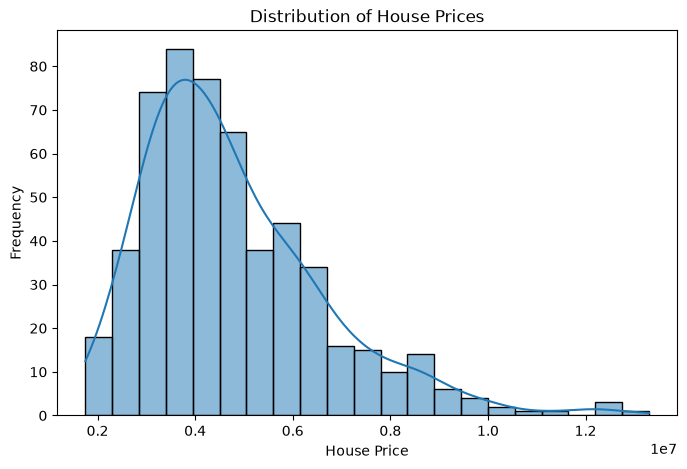

In [5]:
# Distribution of house prices

plt.figure(figsize=(8, 5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

## Feature Selection

The following features were considered potential predictors of house prices:

- **Area:** Larger properties are generally expected to have higher prices.
- **Bedrooms:** The number of bedrooms can influence the overall value of a property.
- **Bathrooms:** Properties with more bathrooms may have higher market value.
- **Stories:** The number of stories can contribute to differences in house prices.
- **Parking:** Availability of parking may affect property value.
- **Air Conditioning:** Properties with air conditioning may have higher prices.
- **Furnishing Status:** The furnishing level can influence the selling price.
- **Location-related and property-amenity features:** These categorical variables may capture differences in property characteristics and buyer preferences.

These features were selected because they represent structural, amenity, and property-characteristic factors that may help explain variations in house prices.

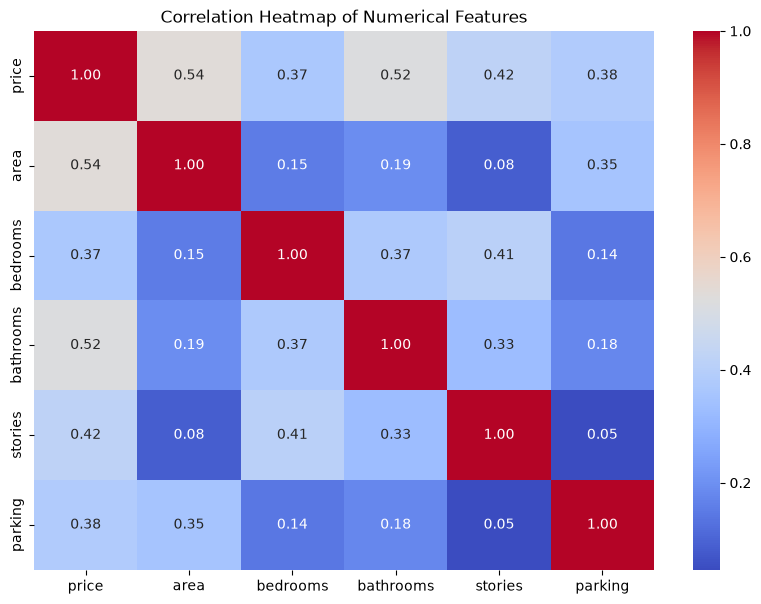

In [6]:
# Correlation analysis for numerical features

plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [7]:
# Prepare features and target variable

X = df.drop("price", axis=1)
y = df["price"]

# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Preprocessing pipelines
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Create the Linear Regression pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Numerical features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Training samples: 436
Testing samples: 109
Numerical features: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical features: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


C:\Users\nazzu\AppData\Local\Temp\ipykernel_35088\2324067028.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [8]:
# Train the Linear Regression model

model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model trained successfully.")
print("\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Model trained successfully.

Model Evaluation:
Mean Squared Error (MSE): 1,754,318,687,330.67
Root Mean Squared Error (RMSE): 1,324,506.96
R² Score: 0.6529


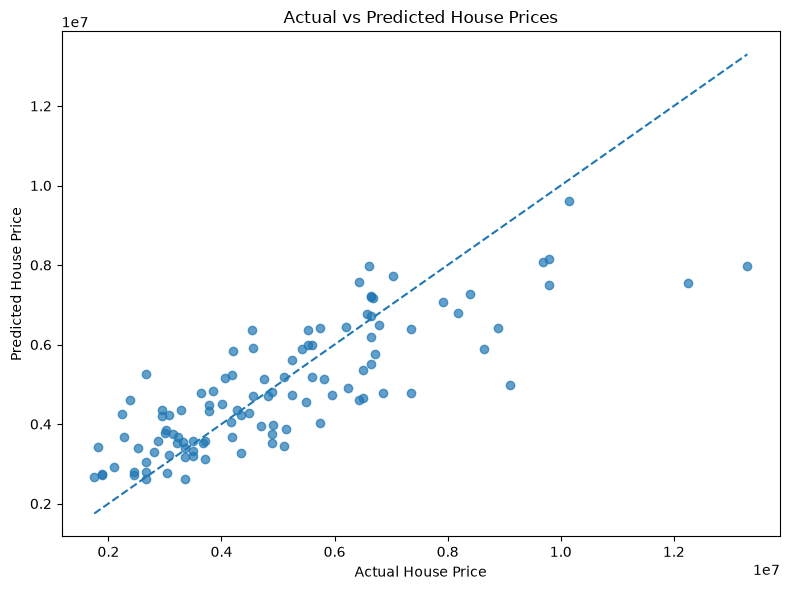

In [9]:
# Actual vs Predicted House Prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.show()

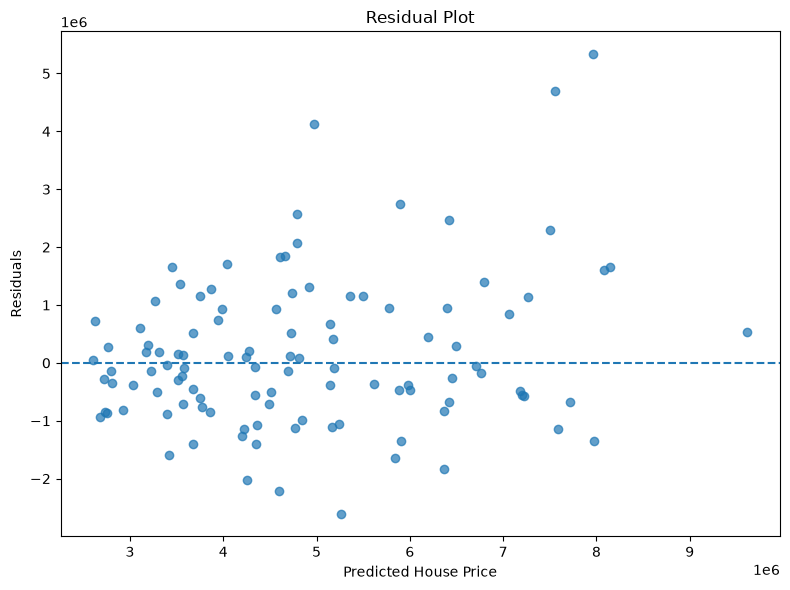

In [10]:
# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

In [11]:
# Coefficient Analysis

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Coefficient"] = coefficient_df["Coefficient"].abs()

coefficient_df = coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("Top features influencing house price:")
display(coefficient_df.head(10))

Top features influencing house price:


,Feature,Coefficient,Absolute_Coefficient
2,num__bathrooms,521879.027748,521879.027748
0,num__area,519552.416340,519552.416340
14,cat__airconditioning_yes,395713.367922,395713.367922
13,cat__airconditioning_no,-395713.367922,395713.367922
3,num__stories,349251.438906,349251.438906
11,cat__hotwaterheating_no,-342324.942669,342324.942669
12,cat__hotwaterheating_yes,342324.942669,342324.942669
15,cat__prefarea_no,-314945.282657,314945.282657
16,cat__prefarea_yes,314945.282657,314945.282657
19,cat__furnishingstatus_unfurnished,-233469.435624,233469.435624


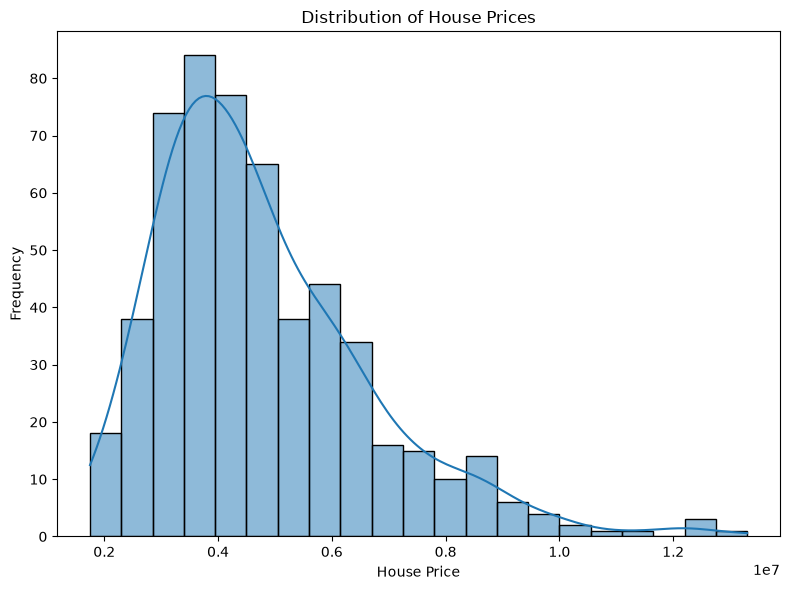

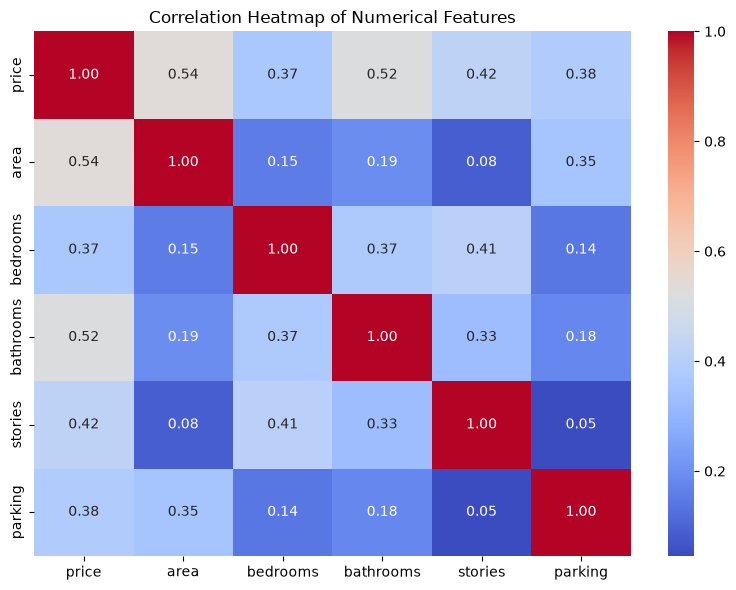

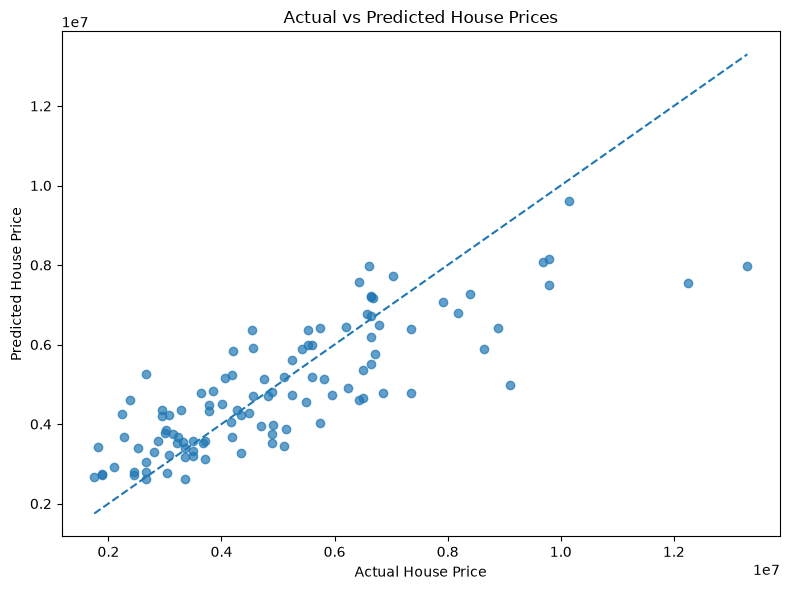

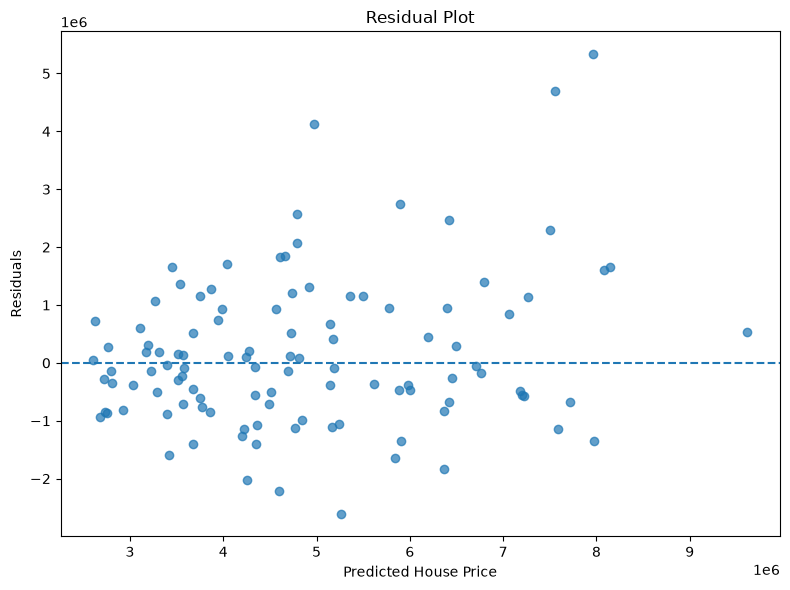

All project visualizations saved successfully.


In [12]:
# Save project visualizations to the outputs folder

import os

os.makedirs("../outputs", exist_ok=True)

# 1. Price Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../outputs/price_distribution.png", dpi=300)
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=300)
plt.show()

# 3. Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.savefig("../outputs/actual_vs_predicted.png", dpi=300)
plt.show()

# 4. Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig("../outputs/residual_plot.png", dpi=300)
plt.show()

print("All project visualizations saved successfully.")